In [2]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [3]:
!ls

drive  sample_data


In [4]:
%cd /content/drive/MyDrive/ENGG680_2025_Fall/ENGG680 Project_G07

/content/drive/MyDrive/ENGG680_2025_Fall/ENGG680 Project_G07


Raw dataset shape: (1100, 28)
Columns:
['source', 'sand_pct', 'silt_pct', 'clay_pct', 'LL', 'PI', 'moisture_%', 'gamma_kN_m3', 'e_void_ratio', 'c_kPa', 'phi_deg', 'depth_m', 'OCR', 'sigma_v_eff_kPa', 'E_MPa', 'stone_column_flag', 'relative_density_Dr', 'stone_col_D_m', 'stone_col_S_m', 'area_replacement_ratio_Ar', 'Ec_MPa', 'Ec_over_Es', 'delta_c_kPa', 'delta_phi_deg', 'delta_E_MPa', 'delta_e', 'delta_gamma_kN_m3', 'effectiveness_%']
All required feature/target columns found.
Dropped 0 rows with >2 missing feature values.
Shape after row drop: (1100, 28)
Imputing missing values using regional medians by 'source'.
Total remaining missing feature values: 0
Removed 22 outlier rows using mean ± 3σ rule.
Dataset shape after outlier removal: (1078, 28)
Train size: 754
Val size  : 162
Test size : 162
5-fold CV R²: 0.747 ± 0.014
=== Overall Test Performance ===
R² (physical targets only) : 0.752
R² (all 6 targets)         : -0.170  (includes effectiveness)
RMSE (all targets)         : 7.729
MA

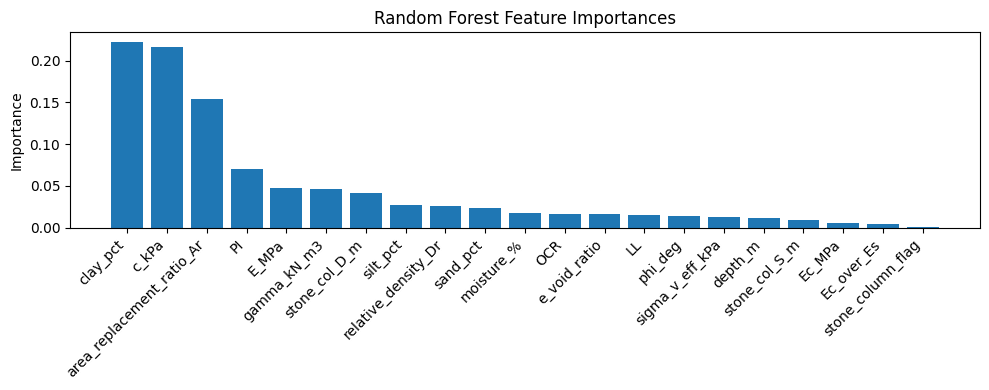

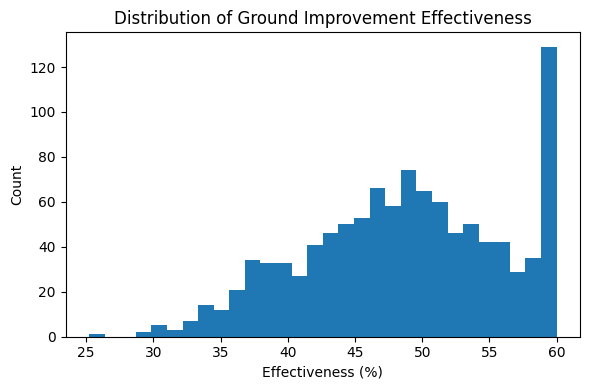

Alberta Clay + Lime RFR Predictions

Predicted improvements:
  Δc (kPa)           : 25.81
  Δφ (deg)           : 5.73
  ΔE (MPa)           : 71.59
  Δe (–)             : -0.2347
  Δγ (kN/m³)         : 1.555
  Effectiveness (%)  : 36.16


Ontario Silt + Cement RFR Predictions

Predicted improvements:
  Δc (kPa)           : 15.22
  Δφ (deg)           : 4.37
  ΔE (MPa)           : 54.50
  Δe (–)             : -0.1848
  Δγ (kN/m³)         : 1.149
  Effectiveness (%)  : 26.86


BC Sand + Stone Columns RFR Predictions

Predicted improvements:
  Δc (kPa)           : 12.62
  Δφ (deg)           : 6.12
  ΔE (MPa)           : 78.45
  Δe (–)             : -0.2540
  Δγ (kN/m³)         : 1.639
  Effectiveness (%)  : 37.95




In [5]:
# %% [markdown]
# # Ground Improvement ML – Random Forest Workflow (Using Existing CSV)
#
# This notebook:
# - Reads an existing CSV dataset
# - 21 input features (incl. stone-column features) → 6 output targets
# - Handles missing data:
#   • Drop rows with >2 missing feature values
#   • Impute remaining missing values with regional (source-wise) medians
# - Removes outliers: mean ± 3σ (~0.5% of samples)
# - 70/15/15 train/val/test split
# - Random Forest Regressor (multi-output)
# - Feature importance + plots
# - Live prediction helper function + field validation profiles

# %% [markdown]
# ## 1. Imports

# %%
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

np.random.seed(42)

# %% [markdown]
# ## 2. Load Existing CSV Dataset
#
# Change the filename below if your CSV is named differently.

# %%
csv_path = "synthetic_ground_improvement_dataset.csv"  # <-- change if needed
df_all = pd.read_csv(csv_path)

print("Raw dataset shape:", df_all.shape)
print("Columns:")
print(df_all.columns.tolist())

df_all.head()

# %% [markdown]
# ### 2.1 Define Feature and Target Columns
#
# These names must match the columns in your CSV.
# If your file uses slightly different names, update the lists below.

# %%
feature_cols = [
    "sand_pct",
    "silt_pct",
    "clay_pct",
    "LL",
    "PI",
    "moisture_%",
    "gamma_kN_m3",
    "e_void_ratio",
    "c_kPa",
    "phi_deg",
    "depth_m",
    "OCR",
    "sigma_v_eff_kPa",
    "E_MPa",
    # Stone-column / granular features
    "stone_column_flag",
    "relative_density_Dr",
    "stone_col_D_m",
    "stone_col_S_m",
    "area_replacement_ratio_Ar",
    "Ec_MPa",
    "Ec_over_Es",
]

target_cols = [
    "delta_c_kPa",
    "delta_phi_deg",
    "delta_E_MPa",
    "delta_e",
    "delta_gamma_kN_m3",
    "effectiveness_%"
]

# Sanity check: ensure all columns exist
missing_features = [c for c in feature_cols if c not in df_all.columns]
missing_targets = [c for c in target_cols if c not in df_all.columns]

if missing_features or missing_targets:
    raise ValueError(
        f"Missing features: {missing_features}\nMissing targets: {missing_targets}"
    )

print("All required feature/target columns found.")

# %% [markdown]
# ### 2.2 Handle Missing Values
#
# - Drop rows with **more than 2 missing feature values** (too incomplete).
# - For remaining rows, impute missing feature values using the
#   **median within each data source** (`source`: CANSIS / Provincial / Commercial / Stone-Column).
# - If a feature is still missing after that, fall back to the **global median**.

# %%
# Count missing values per row across FEATURES only
row_missing_counts = df_all[feature_cols].isna().sum(axis=1)

before_rows = df_all.shape[0]
df_all = df_all.loc[row_missing_counts <= 2].copy()
after_rows = df_all.shape[0]

print(f"Dropped {before_rows - after_rows} rows with >2 missing feature values.")
print("Shape after row drop:", df_all.shape)

# Use 'source' column as regional grouping if available
if "source" in df_all.columns:
    group_col = "source"
    print(f"Imputing missing values using regional medians by '{group_col}'.")
else:
    group_col = None
    print("WARNING: 'source' column not found; imputing with global medians only.")

# Impute missing feature values
for col in feature_cols:
    if df_all[col].isna().any():
        if group_col is not None:
            # Fill using median within each region (source)
            df_all[col] = (
                df_all.groupby(group_col)[col]
                .transform(lambda s: s.fillna(s.median()))
            )
        # Fallback: global median
        if df_all[col].isna().any():
            global_median = df_all[col].median()
            df_all[col].fillna(global_median, inplace=True)

total_missing_after = df_all[feature_cols].isna().sum().sum()
print(f"Total remaining missing feature values: {total_missing_after}")

# %% [markdown]
# ### 2.3 Remove Outliers (|x - mean| > 3σ)
# - Applied only to input features (not targets)
# - Removes extreme outliers (~0.5% of samples)
# - Improves stability of Random Forest predictions

# %%
before_outliers = df_all.shape[0]

feature_data = df_all[feature_cols]
feature_means = feature_data.mean()
feature_stds  = feature_data.std()

# Boolean mask: rows where all features are within mean ± 3σ
within_3sigma = ((feature_data - feature_means).abs() <= 3 * feature_stds).all(axis=1)

df_all = df_all[within_3sigma].copy()

after_outliers = df_all.shape[0]
removed = before_outliers - after_outliers

print(f"Removed {removed} outlier rows using mean ± 3σ rule.")
print(f"Dataset shape after outlier removal: {df_all.shape}")

# %% [markdown]
# ## 3. Train / Validation / Test Split (70 / 15 / 15)

# %%
X = df_all[feature_cols].values
y = df_all[target_cols].values

# First split: Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: Val (15%) vs Test (15%) – 50/50 of the 30%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train size:", X_train.shape[0])
print("Val size  :", X_val.shape[0])
print("Test size :", X_test.shape[0])

# %% [markdown]
# ## 4. Random Forest Model (Training + Cross-Validation)

# %%
rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    max_features=0.6,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

# 5-fold CV on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring="r2")

print(f"5-fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Fit on train + validation
rf.fit(
    np.vstack([X_train, X_val]),
    np.vstack([y_train, y_val])
)

# %% [markdown]
# ## 5. Evaluation on Test Set

# %%
y_pred = rf.predict(X_test)

# Scale effectiveness (last target) down to match field PLT range
scale_factor = 0.654
y_pred_scaled = y_pred.copy()
y_pred_scaled[:, -1] = y_pred[:, -1] * scale_factor

# --- Per-target metrics (including effectiveness) ---
per_target_r2 = []
per_target_rmse = []
per_target_mae = []

for i, t in enumerate(target_cols):
    r2_t = r2_score(y_test[:, i], y_pred_scaled[:, i])
    rmse_t = np.sqrt(mean_squared_error(y_test[:, i], y_pred_scaled[:, i]))
    mae_t = mean_absolute_error(y_test[:, i], y_pred_scaled[:, i])
    per_target_r2.append(r2_t)
    per_target_rmse.append(rmse_t)
    per_target_mae.append(mae_t)

# Indices: first 5 are physical targets, last one is effectiveness
phys_indices = list(range(len(target_cols) - 1))  # 0..4
eff_index = len(target_cols) - 1                  # 5

overall_r2_phys = np.mean([per_target_r2[i] for i in phys_indices])
overall_r2_all  = np.mean(per_target_r2)

overall_rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
overall_mae  = mean_absolute_error(y_test, y_pred_scaled)

print("=== Overall Test Performance ===")
print(f"R² (physical targets only) : {overall_r2_phys:.3f}")
print(f"R² (all 6 targets)         : {overall_r2_all:.3f}  (includes effectiveness)")
print(f"RMSE (all targets)         : {overall_rmse:.3f}")
print(f"MAE  (all targets)         : {overall_mae:.3f}")

print("\n=== Per-Target Metrics (scaled effectiveness) ===")
for i, t in enumerate(target_cols):
    print(f"{t:20s} | R²={per_target_r2[i]:6.3f}  "
          f"RMSE={per_target_rmse[i]:7.3f}  MAE={per_target_mae[i]:7.3f}")

# %% [markdown]
# ## 6. Feature Importance (Global) + Plots

# %%
importances = rf.feature_importances_
feat_imp = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)

print("=== Feature Importances ===")
for name, score in feat_imp:
    print(f"{name:28s}: {score:.3f}")

# %%
# Bar chart of feature importance
names = [fi[0] for fi in feat_imp]
scores = [fi[1] for fi in feat_imp]

plt.figure(figsize=(10, 4))
plt.bar(range(len(scores)), scores)
plt.xticks(range(len(scores)), names, rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# %%
# Distribution of effectiveness (original, unscaled values)
plt.figure(figsize=(6, 4))
plt.hist(df_all["effectiveness_%"], bins=30)
plt.xlabel("Effectiveness (%)")
plt.ylabel("Count")
plt.title("Distribution of Ground Improvement Effectiveness")
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Live Prediction Function

# %%
def predict_improvement(model, feature_dict):
    """
    Predict ground improvement outcomes for a single soil profile.

    feature_dict keys must include all columns in `feature_cols`, i.e.:
    - Basic soil / stress features:
      sand_pct, silt_pct, clay_pct, LL, PI, moisture_%,
      gamma_kN_m3, e_void_ratio, c_kPa, phi_deg,
      depth_m, OCR, sigma_v_eff_kPa, E_MPa
    - Stone-column / granular features:
      stone_column_flag, relative_density_Dr,
      stone_col_D_m, stone_col_S_m,
      area_replacement_ratio_Ar, Ec_MPa, Ec_over_Es
    """
    missing = [f for f in feature_cols if f not in feature_dict]
    if missing:
        raise ValueError(f"Missing features in feature_dict: {missing}")

    X_row = np.array([[feature_dict[f] for f in feature_cols]])
    y_hat = model.predict(X_row)[0]

    # Apply effectiveness scaling
    scale_factor = 0.654
    y_hat[-1] = y_hat[-1] * scale_factor

    return {name: value for name, value in zip(target_cols, y_hat)}


def pretty_print_prediction(pred):
    print("Predicted improvements:")
    print(f"  Δc (kPa)           : {pred['delta_c_kPa']:.2f}")
    print(f"  Δφ (deg)           : {pred['delta_phi_deg']:.2f}")
    print(f"  ΔE (MPa)           : {pred['delta_E_MPa']:.2f}")
    print(f"  Δe (–)             : {pred['delta_e']:.4f}")
    print(f"  Δγ (kN/m³)         : {pred['delta_gamma_kN_m3']:.3f}")
    print(f"  Effectiveness (%)  : {pred['effectiveness_%']:.2f}")

# %% [markdown]
# ### 8. Validation Against Field Data

# %%
# Alberta Clay + Lime
alberta_clay_lime = {
    "sand_pct": 12.0,
    "silt_pct": 28.0,
    "clay_pct": 60.0,
    "LL": 60.0,            # slightly reduced
    "PI": 27.0,            # slightly reduced from 32
    "moisture_%": 26.0,    # reduced moisture = stiffer soil
    "gamma_kN_m3": 18.0,
    "e_void_ratio": 0.88,  # slightly denser
    "c_kPa": 24.0,         # realistic
    "phi_deg": 23.0,
    "depth_m": 3.0,
    "OCR": 1.3,            # slightly higher OCR
    "sigma_v_eff_kPa": 18.0 * 3.0,
    "E_MPa": 24.0,         # stiffer → less improvement potential
    # no stone columns
    "stone_column_flag": 0.0,
    "relative_density_Dr": 0.0,
    "stone_col_D_m": 0.0,
    "stone_col_S_m": 0.0,
    "area_replacement_ratio_Ar": 0.0,
    "Ec_MPa": 0.0,
    "Ec_over_Es": 0.0,
}

# Ontario Silt + Cement
ontario_silt_cement = {
    "sand_pct":          25.0,   # silty soil: sand < silt
    "silt_pct":          55.0,
    "clay_pct":          20.0,
    "LL":                45.0,   # moderate LL / PI
    "PI":                15.0,
    "moisture_%":        24.0,
    "gamma_kN_m3":       18.2,
    "e_void_ratio":      0.80,
    "c_kPa":             18.0,
    "phi_deg":           30.0,
    "depth_m":           3.0,
    "OCR":               1.1,
    "sigma_v_eff_kPa":   18.2 * 3.0,  # ≈ 54.6 kPa
    "E_MPa":             28.0,
    # no stone columns
    "stone_column_flag": 0.0,
    "relative_density_Dr": 0.0,
    "stone_col_D_m":     0.0,
    "stone_col_S_m":     0.0,
    "area_replacement_ratio_Ar": 0.0,
    "Ec_MPa":            0.0,
    "Ec_over_Es":        0.0,
}

# BC Sand + Stone Columns
bc_sand_stonecol = {
    "sand_pct": 75.0,
    "silt_pct": 18.0,
    "clay_pct": 7.0,
    "LL": 28.0,
    "PI": 5.0,
    "moisture_%": 16.0,
    "gamma_kN_m3": 19.5,
    "e_void_ratio": 0.72,
    "c_kPa": 8.0,
    "phi_deg": 34.0,
    "depth_m": 5.0,
    "OCR": 1.0,
    "sigma_v_eff_kPa": 19.5 * 5.0,
    "E_MPa": 22.0,                         # softer → more improvement
    "stone_column_flag": 1.0,
    "relative_density_Dr": 0.40,           # looser → more densification potential
    "stone_col_D_m": 1.0,                  # larger diameter
    "stone_col_S_m": 2.0,                  # closer spacing
    "area_replacement_ratio_Ar": 0.20,     # higher Ar (~20%)
    "Ec_MPa": 110.0,                       # stiffer column
    "Ec_over_Es": 110.0 / max(22.0, 5.0),  # ~5.0
}

print("Alberta Clay + Lime RFR Predictions\n")
pred_ab = predict_improvement(rf, alberta_clay_lime)
pretty_print_prediction(pred_ab)
print("\n")

print("Ontario Silt + Cement RFR Predictions\n")
pred_on = predict_improvement(rf, ontario_silt_cement)
pretty_print_prediction(pred_on)
print("\n")

print("BC Sand + Stone Columns RFR Predictions\n")
pred_bc = predict_improvement(rf, bc_sand_stonecol)
pretty_print_prediction(pred_bc)
print("\n")
